# Fast and Sure-ious Quantum Process Tomography

Companion notebook for *Fast and Sure-ious Quantum Process Tomography*, A. Afham, S. Sen and M. Tomamichel.

A quantum channel $\Phi$ is estimated by running state tomography on copies of its Choi state $\rho = \mathfrak{C}(\Phi)$ and then repairing the estimate, which is a density matrix but not the Choi state of a channel: its input marginal is not maximally mixed. The paper shows that the folklore repair, the **partial normalization**

$$\mathrm{N}_{\mathsf A}(\hat\rho) \;=\; \tfrac{1}{d_{\mathsf A}}\,\bigl(\hat\rho_{\mathsf A}^{-1/2}\otimes I_{\mathsf B}\bigr)\,\hat\rho\,\bigl(\hat\rho_{\mathsf A}^{-1/2}\otimes I_{\mathsf B}\bigr),$$

is the *exact* projection onto the Choi states of channels in fidelity. It is a single congruence, it preserves the Choi rank, and it costs one $d_{\mathsf A}\times d_{\mathsf A}$ eigendecomposition, so any state-tomography algorithm with a fidelity guarantee lifts to process tomography at the cost of a constant factor in accuracy.


In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

# On Colab, uncomment (set the URL to the published repository first):
# !git clone -q https://github.com/<user>/<repo>.git && cd <repo>

from fpls import *          # noqa: F403  -- the algorithm
from fplsplots import (fig_headline, fig_hip_iterations,
                       fig_threshold_strategies, fig_spectra, fig_accuracy,
                       fig_channel_robustness, fig_fullrank_tradeoff,
                       table_head_to_head)
import numpy as np

# The paper's figure style: matplotlib's built-in ggplot, with only the output
# settings and the Computer Modern math font overridden (see fpls._STYLE).
# fplsplots applies it on import; the call here makes it explicit and lets you
# style your own plots the same way.
plt = use_style()


### Notation

| code | paper | meaning |
|---|---|---|
| `rho` | $\rho = \mathfrak{C}(\Phi)$ | Choi state of the unknown channel, trace one |
| `dA`, `dB`, `d` | $d_{\mathsf A}, d_{\mathsf B}, d_{\mathsf{AB}}$ | input, output and Choi dimensions |
| `rho_ls` | $\hat\rho_{\mathrm{LS}}$ | least-squares estimate: Hermitian, unit trace, indefinite |
| `rho_hat` | $\hat\rho$ | density estimate: the thresholded, PSD, unit-trace estimate |
| `bernstein_radius(d, N)` | $\beta_N$ | concentration radius of $\hat\rho_{\mathrm{LS}}$ at confidence $\delta = 0.05$ |
| `threshold_density_estimate(H, tau)` | Algorithm 3 | spectrum thresholded at $\tau$, trace restored |
| `fidelity_projection(rho, dA)` | $\Pi_{\mathcal C}= \mathrm{N}_{\mathsf A}$ | the partial normalization, Theorem 1 |
| `normalise_kraus(Ks)` | Theorem 6 | the same projection on Kraus operators, $K_i \mapsto K_i R^{-1/2}$ |
| `choi_rank(rho)` | $\operatorname{rank}$ | eigenvalues above $10^{-10}$, the paper's cutoff |
| `paper_rng(...)` | | the frozen seed streams the cached sweeps were drawn from |

## 1. The estimator on one small instance

The headline channel: an equal mixture of the quantum Fourier transform with one Haar-random unitary, so the Choi rank is exactly 2 and both nonzero Choi eigenvalues sit near $1/2$. Two qubits in, two out, so $d_{\mathsf{AB}} = 16$.

In [2]:
nq = 2                                   # qubits per side
dA = dB = 2 ** nq
rho = rank_two_channel(nq, paper_rng(PAPER_SEED, 1))

lam = np.linalg.eigvalsh(rho)[::-1]
print(f"d_A = d_B = {dA},  d_AB = {dA * dB}")
print(f"true Choi rank                r       = {choi_rank(rho)}")
print(f"smallest nonzero eigenvalue   lambda_r = {lam[choi_rank(rho) - 1]:.4f}")
print(f"is a channel (PSD, trace 1, maximally mixed marginal): {is_channel(rho, dA)}")

d_A = d_B = 4,  d_AB = 16
true Choi rank                r       = 2
smallest nonzero eigenvalue   lambda_r = 0.2438
is a channel (PSD, trace 1, maximally mixed marginal): True


Now the protocol: simulate $N$ single-copy local Pauli measurements, form the least-squares estimate, threshold its spectrum at $\tau = \beta_N$, and apply the fidelity projection. The threshold sits **above** the noise -- that is what makes rank recovery provable -- and `noise` below is the realized $\|\hat\rho_{\mathrm{LS}} - \rho\|_\infty$, which the concentration bound says stays under $\beta_N$ with probability $1-\delta$.

In [3]:
print(f"{'N':>10} {'beta_N':>9} {'noise':>9} {'rank':>6} {'1 - F':>11}")
for N in (10 ** 4, 10 ** 5, 10 ** 6, 10 ** 7, 10 ** 8):
    r = fpls(rho, N, paper_rng(PAPER_SEED, 7, N), dA=dA)
    print(f"{N:>10.0e} {r['beta_N']:9.4f} {r['noise']:9.4f} {r['rank']:>6} {r['infidelity']:11.3e}")

assert r["noise"] < r["beta_N"], "the realized noise left the concentration event"
assert r["rank"] == choi_rank(rho), "rank not recovered at the largest N"
assert r["infidelity"] < 1e-5, "infidelity too large at the largest N"
print("\nrank recovered and the estimate is accurate at the largest N")

         N    beta_N     noise   rank       1 - F
     1e+04    0.3530    0.1099      1   1.437e-01
     1e+05    0.1116    0.0368      2   9.370e-04
     1e+06    0.0353    0.0127      2   1.105e-04
     1e+07    0.0112    0.0034      2   4.775e-06
     1e+08    0.0035    0.0012      2   8.894e-07

rank recovered and the estimate is accurate at the largest N


The estimate is a channel, and the Kraus route of Theorem 6 -- which never forms a $d_{\mathsf{AB}} \times d_{\mathsf{AB}}$ matrix -- gives the same answer as the dense congruence.

In [4]:
dense = fpls(rho, 10 ** 6, paper_rng(PAPER_SEED, 7, 10 ** 6), dA=dA)
kraus = fpls(rho, 10 ** 6, paper_rng(PAPER_SEED, 7, 10 ** 6), dA=dA, kraus=True)

print(f"output is a channel                {is_channel(dense['estimate'], dA)}")
print(f"Kraus operators returned           {len(kraus['kraus'])}  (= the Choi rank)")
print(f"sum_i K_i^dag K_i = I_A            "
      f"{np.allclose(sum(K.conj().T @ K for K in kraus['kraus']), np.eye(dA))}")
print(f"dense vs Kraus, max |difference|   "
      f"{np.abs(dense['estimate'] - kraus['estimate']).max():.2e}")

assert is_channel(dense["estimate"], dA)
assert np.allclose(dense["estimate"], kraus["estimate"], atol=1e-12)
print("\nthe two implementations of the projection agree to machine precision")

output is a channel                True
Kraus operators returned           2  (= the Choi rank)
sum_i K_i^dag K_i = I_A            True
dense vs Kraus, max |difference|   1.65e-16

the two implementations of the projection agree to machine precision


**Parity.** `sweeps.py` runs the pipeline live; `fpls.py` is the same code path the
paper's own sweeps used. The check below rebuilds one entry of the shipped
headline sweep from scratch and compares it against the stored value.


In [5]:
import json
cache = json.load(open("data/headline.json"))
N, trial = 10 ** 6, 0
i = cache["shots"].index(N)

rho_big = rank_two_channel(4, paper_rng(PAPER_SEED, 1))
live = fpls(rho_big, N, paper_rng(PAPER_SEED, 1, int(np.log10(N) * 10), trial), dA=16)

print(f"cached     1 - F = {cache['fpls']['inf'][i][trial]:.15e}   rank {cache['fpls']['rank'][i][trial]}")
print(f"recomputed 1 - F = {live['infidelity']:.15e}   rank {live['rank']}")

assert live["infidelity"] == cache["fpls"]["inf"][i][trial]
assert live["rank"] == cache["fpls"]["rank"][i][trial]
print("\nidentical to the last bit")

cached     1 - F = 2.489643269298014e-03   rank 2
recomputed 1 - F = 2.489643269298014e-03   rank 2

identical to the last bit


## 2. The figures, recomputed

Every figure below is **recomputed in its cell**, including the wall-clock ones.
Each cell opens with its parameters and states, next to them, the values that
produce the paper's figure. The defaults are small so the whole notebook runs in
under a minute; set the parameters to the paper's values to reproduce its curves,
at the cost stated in the cell.

The timing figures measure *your* machine, so their absolute seconds will differ
from the paper's. The claim those figures make is the **scaling**, and that is
what reproduces.

The PLS baseline is the published implementation of Surawy-Stepney, Kahn, Kueng
and Guta, BSD-3-Clause. If it is not on disk the cells still run and omit that
curve; clone it beside this folder to have it computed live:

```
git clone https://github.com/Hannoskaj/Hyperplane_Intersection_Projection.git
```


In [6]:
from sweeps import (PAPER_SHOTS, have_hip, channel, sweep_headline, sweep_accuracy,
                    sweep_spectra, sweep_thresholds, sweep_robustness,
                    sweep_cost_ladder, sweep_hip_iterations, sweep_table)

print("PLS baseline available:", have_hip())


PLS baseline available: True


### Figure 2: the cost of the closed form, and what it buys

Left, timed here: the wall-clock of one TP regularization against Choi dimension,
for the same calibrated density estimate regularized two or three ways. Each
instance is calibrated to a fixed distance from the channel set first, so
dimension rather than estimate quality is the variable.

Right: the recovered Choi rank over the infidelity of the same estimates. Both
pipelines post-process the **same** least-squares estimate; ours thresholds at
$\tau = \beta_N$ and applies the fidelity projection, PLS thresholds at
$\tau = -\lambda_{\min}$ and applies HIP. The dotted guides are the two
*predicted* rates, not fits.


  N = 1e4.0  (1/5)

  N = 1e5.0  (2/5)

  N = 1e6.0  (3/5)

  N = 1e7.0  (4/5)

  N = 1e8.0  (5/5)

...

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


at d_AB = 32     HIP    0.003 s   FPLS    0.096 ms   (paper, at 2^10: 52 s against 0.28 ms)
onset of exact rank recovery      N = 1e+06        (paper: 1e6)
PLS-QPT rank over all N, trials   222-241 of 256   (paper: 202-241 of 256)
slopes past the onset             FPLS -1.01, PLS-QPT -0.48
  (the guides are the PREDICTED rates 1/N and 1/sqrt(N), not fits; Fig. 5 quotes the fitted values)


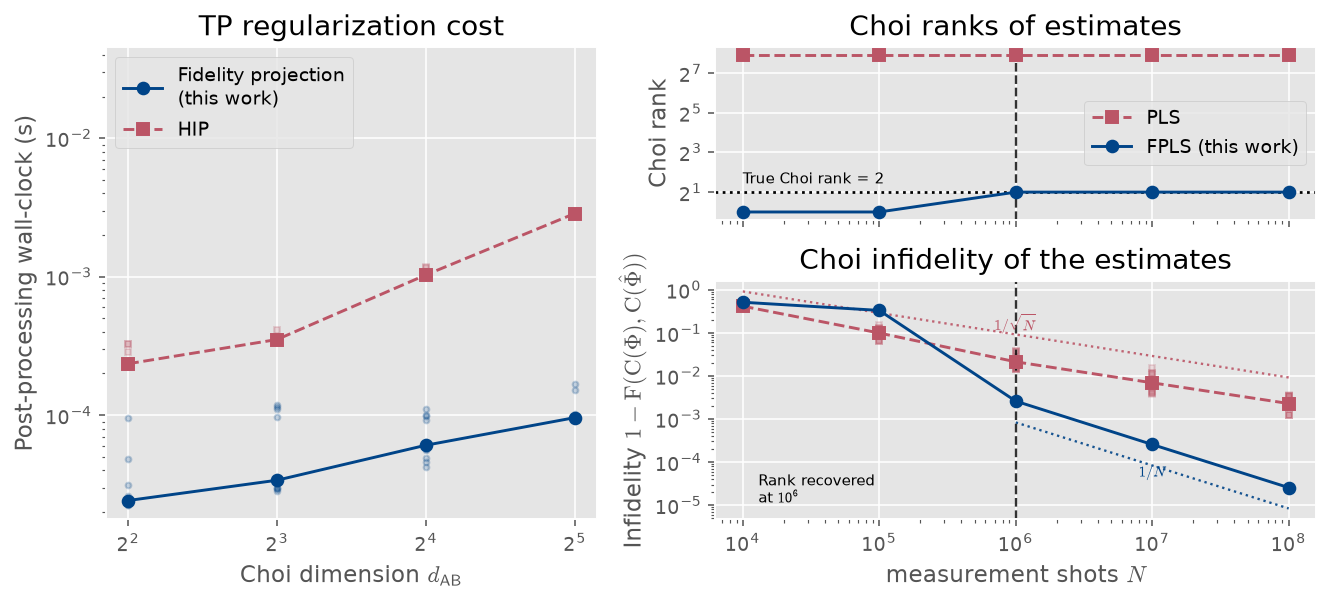

In [7]:
# ---- parameters -------------------------------------------------------------
NQ     = 4                  # qubits per side, so d_AB = 4^NQ.   PAPER: 4  (d_AB = 256)
SHOTS  = [1e4, 1e5, 1e6, 1e7, 1e8]   #                            PAPER: PAPER_SHOTS (1e4..1e10)
TRIALS = 10                  # trials per shot count.              PAPER: 10
SEED   = 20260817           # the paper's seed.                   PAPER: 20260817
LADDER_DIMS = (4, 8, 16, 32)  # Choi dims timed on the left, or (dA, dB) pairs.
                            #                                     PAPER: 4 .. 1024
LADDER_SDP  = False         # also time the diamond-norm SDP (needs cvxpy). PAPER: True, to 128
# PAPER FIGURE: NQ=4, SHOTS=PAPER_SHOTS, TRIALS=10, LADDER_DIMS=(4,...,1024),
#               LADDER_SDP=True  (hours: the SDP alone is 86 s per instance at 2^7)
# A power of two is split as evenly as it allows, so 64 is 8x8 and 128 is 8x16;
# the odd powers are the rectangular points that interleave the square ones.
# -----------------------------------------------------------------------------
data   = sweep_headline(nq=NQ, shots=SHOTS, trials=TRIALS, seed=SEED)
ladder = sweep_cost_ladder(dims=LADDER_DIMS, trials=TRIALS, seed=SEED, sdp=LADDER_SDP)
fig_headline(data=data, ladder=ladder);


### Figure 3: rank preservation

Three columns from the **same** density estimate: the estimate itself, then its
two TP regularizations. The fidelity projection is a congruence by an invertible
matrix, so it returns the rank of its input exactly. HIP's TP step and its final
mixing with the maximally mixed state fill in every remaining direction.


rank-2 channel               true rank   2   FPLS   2 (1-F 1.10e-04)   PLS-QPT  12 (1-F 1.68e-03)
amplitude damping, rank 2    true rank   4   FPLS   3 (1-F 6.25e-03)   PLS-QPT  14 (1-F 5.09e-03)


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


paper: FPLS returns 2 and 4; PLS-QPT returns 225 and 240 of 256


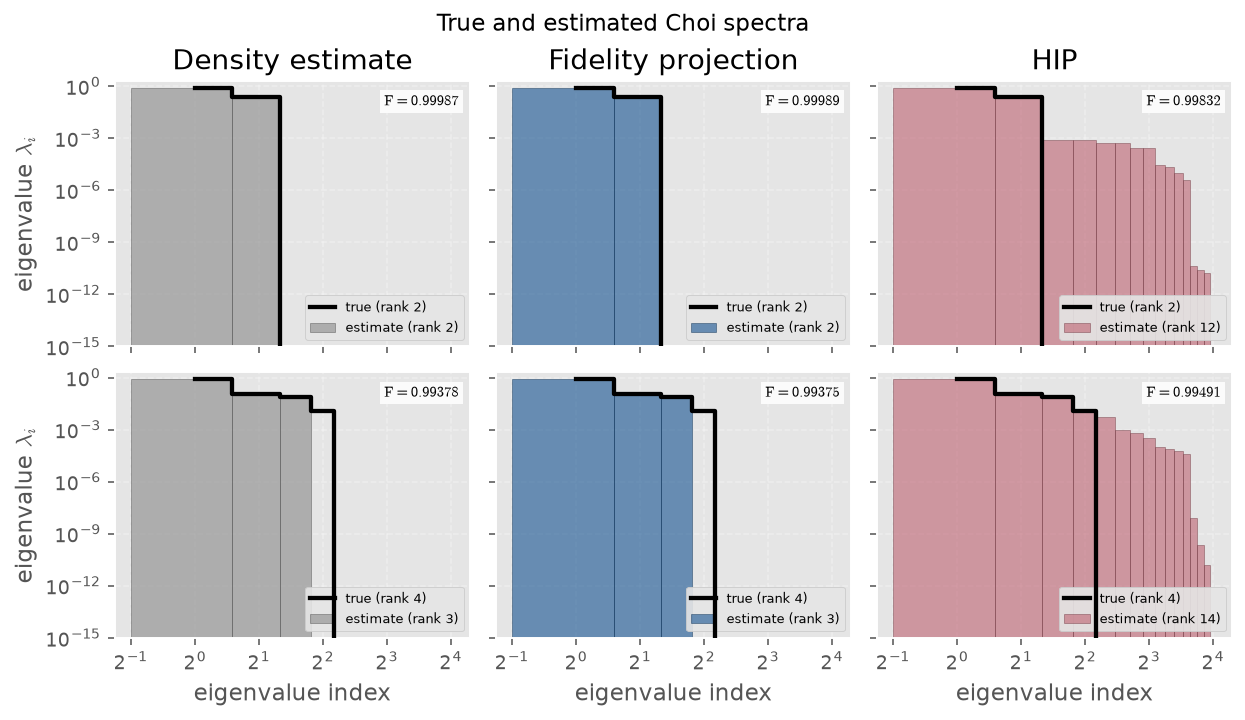

In [8]:
# ---- parameters -------------------------------------------------------------
NQ       = 2                # d_AB = 4^NQ.                        PAPER: 4  (d_AB = 256)
N        = 1e6              # shots.                              PAPER: 1e8
SEED     = 20260817         #                                     PAPER: 20260817
CHANNELS = (("rank2", "rank-2 channel"),
            ("amp_damping_r2", "amplitude damping, rank 2"))
# PAPER FIGURE: NQ=4, N=1e8, and amplitude damping on 2 of 4 qubits (rank 4)
# -----------------------------------------------------------------------------
data = sweep_spectra(channels=CHANNELS, nq=NQ, N=N, seed=SEED)
fig_spectra(data=data);


### Table 1: head to head

Fidelity, TP-regularization wall-clock and storage, for the two pipelines on the
same data. Storage is counted as the table counts it: $r$ Kraus operators for
ours against a dense $d_{\mathsf{AB}} \times d_{\mathsf{AB}}$ matrix for PLS,
whose output is of nearly full rank.


In [9]:
# ---- parameters -------------------------------------------------------------
DIMS   = (16, 64)           # Choi dimensions.                    PAPER: 64 and 1024
N      = 1e6                # shots.                              PAPER: 1e8
TRIALS = 3                  #                                     PAPER: 3
SEED   = 20260817           #                                     PAPER: 20260817
# PAPER TABLE: DIMS=(64, 1024), N=1e8, and a second channel of Choi rank log2(d_AB)
# -----------------------------------------------------------------------------
table_head_to_head(data=sweep_table(dims=DIMS, N=N, trials=TRIALS, seed=SEED))


  d_AB = 16 done

  d_AB = 64 done

N = 1e+06, medians over 3 trials, HIP at tolerance 1e-06
  d_AB  rank |    F (PLS)   F (FPLS) |    t (PLS)   t (FPLS)     ratio |  kB (PLS)  kB (FPLS)   ratio
-----------------------------------------------------------------------------------------------------
    16     2 |   0.995784   0.999894 |     0.001s      0.06ms       15x |       4.1        0.5      8x
    64     2 |   0.986379   0.999604 |     0.018s      0.48ms       38x |      65.5        2.0     32x

paper Table 1: 0.99954 / 0.99999 at 2^6 rank 2, 16 ms against 0.03 ms, 66 kB against 3 kB;
               0.99666 / 0.99984 at 2^10 rank 2, 39 s against 0.37 ms, 16.8 MB against 49 kB


### Figure 4: why the iterative method is expensive

Every instance is calibrated to a common distance from the channel set, so
dimension rather than estimate quality is the variable. The point is that it is
not only the cost of an iteration that grows with dimension but the *number* of
them, which is what the fitted exponent measures.


  rank2 d_pu=0.05: 2 x 2

  rank2 d_pu=0.05: 4 x 4

  rank2 d_pu=0.05: 8 x 8

  rank2 d_pu=0.05: 16 x 16

  rank2 d_pu=0.2: 2 x 2

...

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


rank2    1.3 d^0.72  3.8 d^0.52
paper: isometry 1.8 d^0.68, 2.3 d^0.62, 1.2 d^0.73, 0.9 d^0.76; exponents 0.48/0.48/0.62/0.75 and 0.29/0.41/0.62/0.76


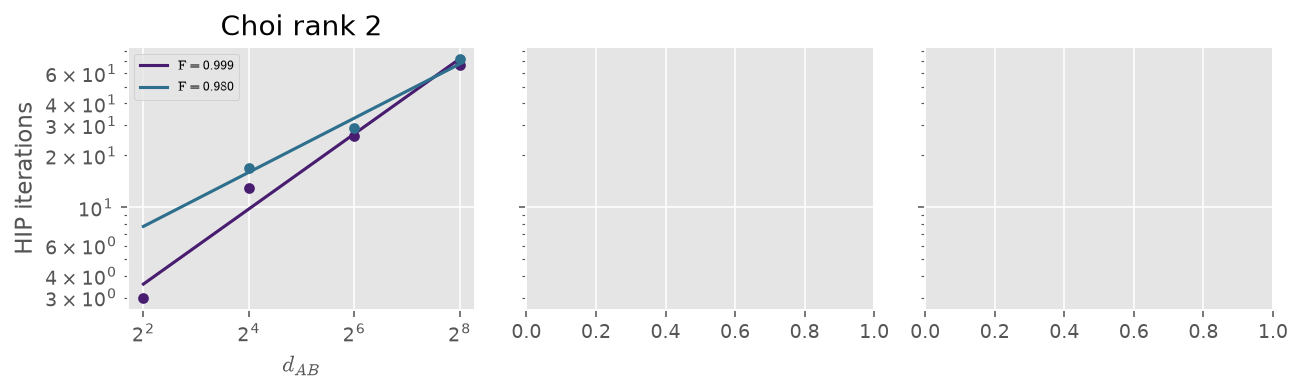

In [10]:
# ---- parameters -------------------------------------------------------------
DIMS    = (4, 16, 64, 256)  # Choi dimensions.                    PAPER: 4 .. 1024
TARGETS = (0.05, 0.2)       # purified distances from the channel set.
                            #                                     PAPER: 0.05, 0.1, 0.2, 0.3
TRIALS  = 3                 #                                     PAPER: 10
SEED    = 20260817          #                                     PAPER: 20260817
FAMILY  = (("rank2", "Choi rank 2"),)   # PAPER: isometry, rank log2(d_AB), full rank
# PAPER FIGURE: DIMS to 1024, four targets, three channel families, TRIALS=10
# -----------------------------------------------------------------------------
data = sweep_hip_iterations(dims=DIMS, targets=TARGETS, families=FAMILY,
                            trials=TRIALS, seed=SEED)
fig_hip_iterations(data=data);


### Figure 5: the same estimates in three metrics

The quadratic gain from recovering the rank is a property of the **fidelity**:
in the two norms all three pipelines converge at $1/\sqrt{N}$ and differ only by
a constant.


  N = 1e4.0  (1/5)

  N = 1e5.0  (2/5)

  N = 1e6.0  (3/5)

  N = 1e7.0  (4/5)

  N = 1e8.0  (5/5)

...

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


onsets: beta_N 1e+05, beta_N/2 1e+04        (paper: 1e6 and 3e5)
  exponent (inf)  FPLS -1.05   PLS-QPT -0.46      (paper: -1.00 and -0.50)
  exponent (tr )  FPLS -0.52   PLS-QPT -0.50      (paper: -0.50 and -0.49)
  exponent (fro)  FPLS -0.52   PLS-QPT -0.51      (paper: -0.50 and -0.50)
  infidelity ratio at N = 1e+06         24x
  infidelity ratio at N = 1e+08        367x
  (paper: 8x, 0.9e2, 1.0e3)
  fpls_half  its onset is the first shot count here, so there is no pre-onset point   (paper: 3.4x and 6.0x)
  fpls_beta  behind PLS-QPT by 4.4x at the last N before its onset   (paper: 3.4x and 6.0x)
  at N = 1e+08 ahead by 1.3x in trace and 1.1x in Frobenius   (paper: 1.5x, 1.3x)
  before its onset beta_N/2 is behind by up to n/a in trace and n/a in Frobenius   (paper: 2.0x, 3.0x)


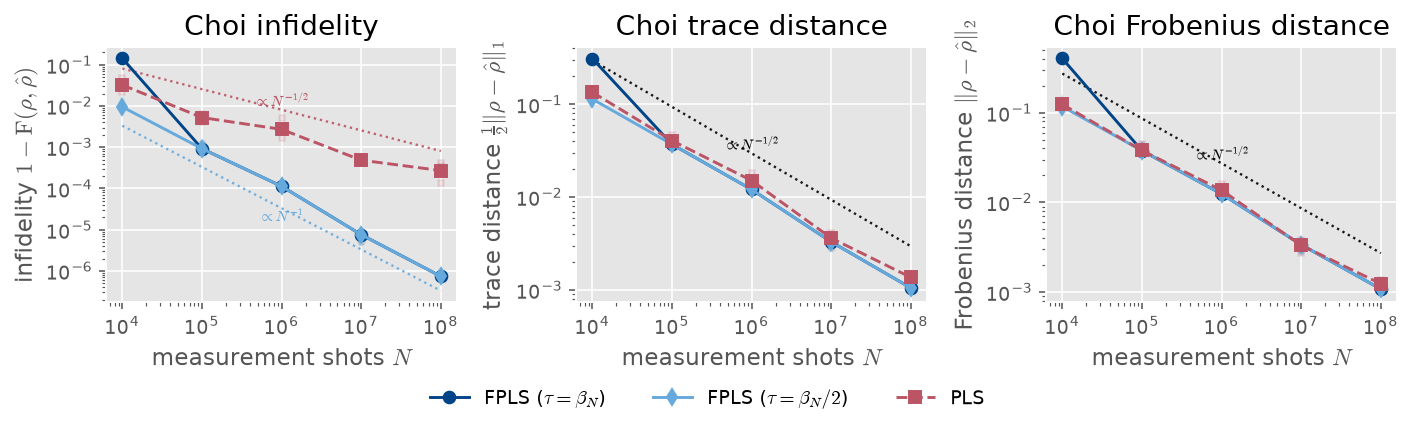

In [11]:
# ---- parameters -------------------------------------------------------------
NQ     = 2                  # d_AB = 4^NQ.                        PAPER: 4  (d_AB = 256)
SHOTS  = [1e4, 1e5, 1e6, 1e7, 1e8]   #                            PAPER: PAPER_SHOTS
TRIALS = 3                  #                                     PAPER: 10
SEED   = 20260817           #                                     PAPER: 20260817
# PAPER FIGURE: NQ=4, SHOTS=PAPER_SHOTS, TRIALS=10, SEED=20260817  (~1 h with the PLS arm)
# -----------------------------------------------------------------------------
data = sweep_accuracy(nq=NQ, shots=SHOTS, trials=TRIALS, seed=SEED)
fig_accuracy(data=data);


### Figure 6: across channels of low Choi rank

The onset moves with the smallest nonzero Choi eigenvalue, as the analysis
predicts: the Werner-Holevo channel has rank 28 but a flat spectrum, so it
recovers two decades before rank-8 amplitude damping. The paper's version has
two further rows showing the spectra at $N = 10^6$ and $10^{10}$; recomputed
here, the figure carries the rank and accuracy rows.


  N = 1e4.0  (1/5)

  N = 1e5.0  (2/5)

  N = 1e6.0  (3/5)

  N = 1e7.0  (4/5)

  N = 1e8.0  (5/5)

...

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


paper: onsets 3e5, 1e7, 1e9, 1e7; PLS-QPT 49-63 of 64 per trial; exponents -1.0 against -0.5 to -0.6


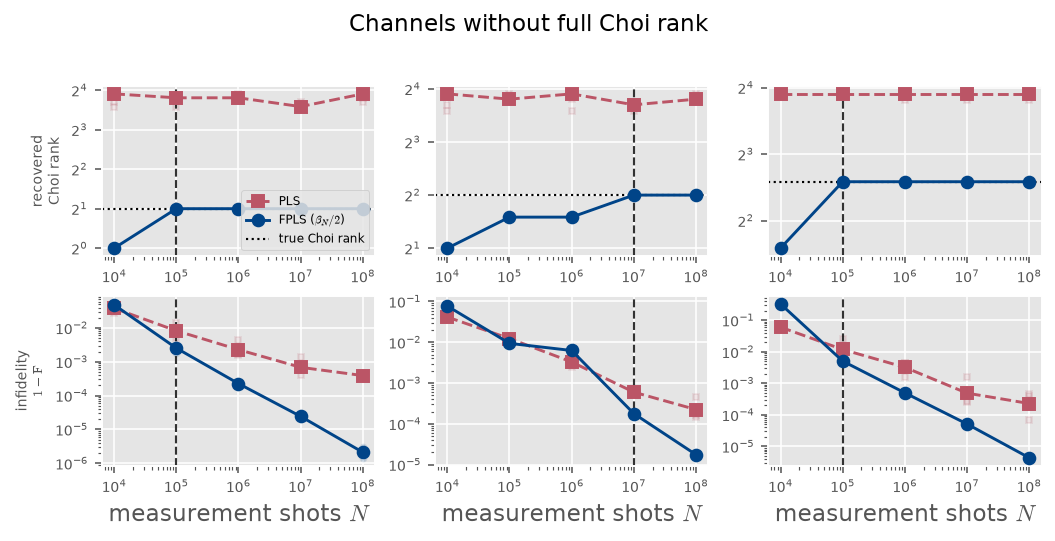

In [12]:
# ---- parameters -------------------------------------------------------------
NQ       = 2                # d_AB = 4^NQ.                        PAPER: 3  (d_AB = 64)
SHOTS    = [1e4, 1e5, 1e6, 1e7, 1e8]   #                          PAPER: PAPER_SHOTS
TRIALS   = 3                #                                     PAPER: 10
SEED     = 20260817         #                                     PAPER: 20260817
CHANNELS = (("amp_damping_r1", "amp. damping, rank 2"),
            ("amp_damping_r2", "amp. damping, rank 4"),
            ("werner_holevo",  "Werner--Holevo"))
# PAPER FIGURE: NQ=3, four columns -- amplitude damping on 1, 2 and 3 qubits
#               (Choi ranks 2, 4, 8) and Werner-Holevo (rank 28)
# -----------------------------------------------------------------------------
data = sweep_robustness(CHANNELS, nq=NQ, shots=SHOTS, trials=TRIALS, seed=SEED)
fig_channel_robustness(data=data);


### Figure 7: where this estimator loses

At full Choi rank there is no gap to place a threshold in, so the Bernstein rule
admits a direction only once the data resolves it, and the returned rank climbs
with $N$ without reaching the truth. PLS, which keeps every direction, is the
better estimator here. The figure is in the paper for that reason.


  N = 1e4.0  (1/5)

  N = 1e5.0  (2/5)

  N = 1e6.0  (3/5)

  N = 1e7.0  (4/5)

  N = 1e8.0  (5/5)

...

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


paper: no FPLS onset within N <= 1e10.  The paper's "ranks 51 to 64" is the range of
       the PLS-QPT estimates shown in the spectrum panels of Fig. 7, a different
       set of estimates from the rank sweep summarised above


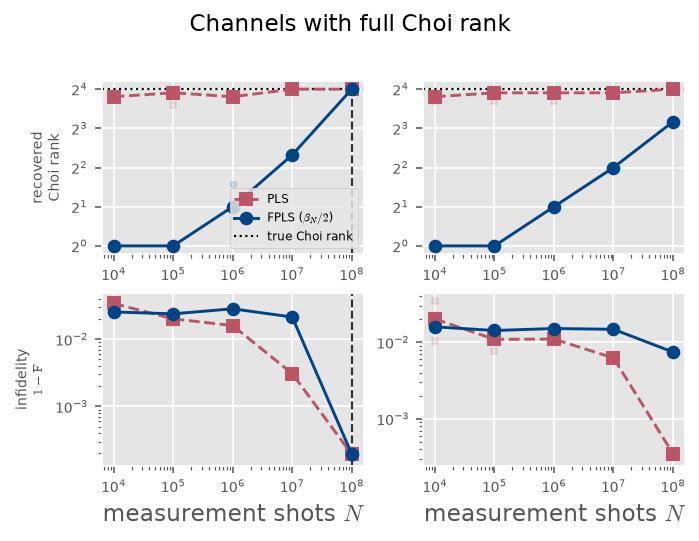

In [13]:
# ---- parameters -------------------------------------------------------------
NQ       = 2                # d_AB = 4^NQ.                        PAPER: 3  (d_AB = 64)
SHOTS    = [1e4, 1e5, 1e6, 1e7, 1e8]   #                          PAPER: PAPER_SHOTS
TRIALS   = 3                #                                     PAPER: 10
SEED     = 20260817         #                                     PAPER: 20260817
CHANNELS = (("depolarizing_p5",  "depolarizing, $p=0.05$"),
            ("qft_depol_p3",     "QFT + 3% depol."))
# PAPER FIGURE: NQ=3, four columns -- global depolarizing p=0.05, QFT + 3% depol.,
#               5% depolarizing per qubit, and QFT + 3% BCSZ
# -----------------------------------------------------------------------------
data = sweep_robustness(CHANNELS, nq=NQ, shots=SHOTS, trials=TRIALS, seed=SEED)
fig_fullrank_tradeoff(data=data);


### Figure 8: the threshold rules

This one needs nothing cached: all four curves are the same thresholded
estimator followed by the same fidelity projection, so they differ only in
$\tau$. $\tau = 0$ keeps every positive noise eigenvalue; $\tau = -\lambda_{\min}$
compares two order statistics of the same noise and recovers the rank in about
half the trials at every $N$, so its accuracy is drawn as one median **per
branch**; the Bernstein thresholds sit above the noise and are exact past their
onset.


  N = 1e4.0  (1/5)

  N = 1e5.0  (2/5)

  N = 1e6.0  (3/5)

  N = 1e7.0  (4/5)

  N = 1e8.0  (5/5)

...

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


paper: 6->15 of 64 and 7->18 of 256 at tau = 0; modal rank 4-5 and 2-3 and exact in 3-9 of 10 trials at -lambda_min;
       onsets 3e7 and 1e6 (halved: 1e7 and 3e5), guaranteed onsets 6e7 and 3e6


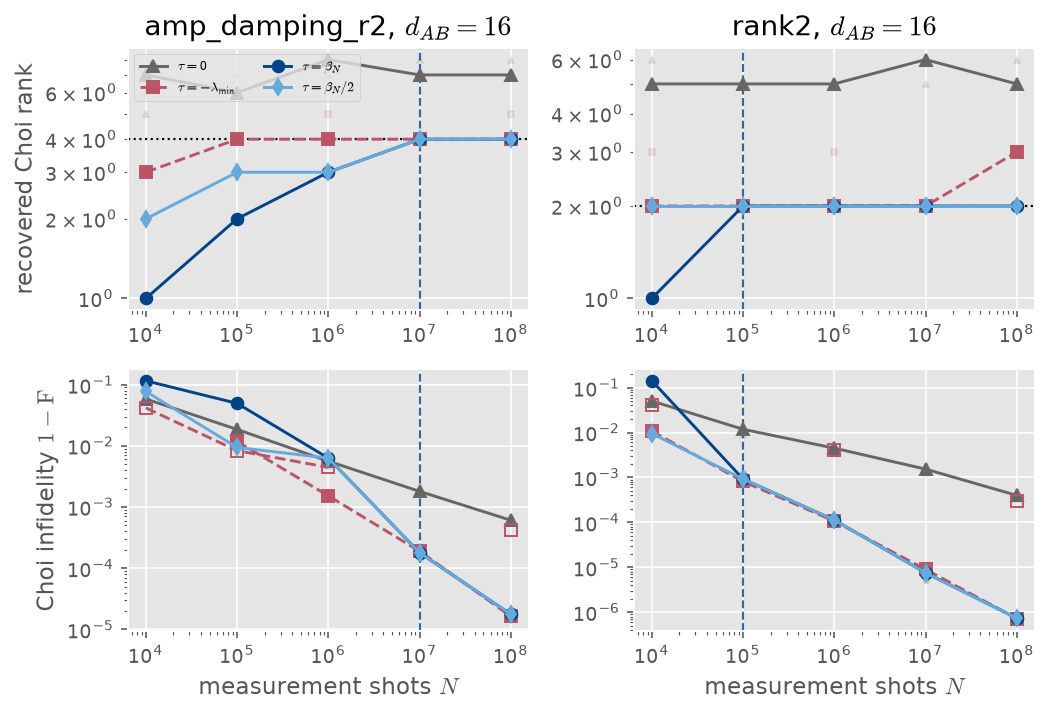

In [14]:
# ---- parameters -------------------------------------------------------------
NQ       = 2                # d_AB = 4^NQ.                        PAPER: 3 and 4
SHOTS    = [1e4, 1e5, 1e6, 1e7, 1e8]   #                          PAPER: 1e3..1e10
TRIALS   = 3                #                                     PAPER: 10
SEED     = 20260817         #                                     PAPER: 20260817
CHANNELS = (("amp_damping_r2", None), ("rank2", None))
# PAPER FIGURE: amplitude damping on 2 of 3 qubits at NQ=3 (d_AB=64, rank 4) and
#               the rank-2 channel at NQ=4 (d_AB=256), shots from 1e3
# -----------------------------------------------------------------------------
data = sweep_thresholds(channels=CHANNELS, nq=NQ, shots=SHOTS, trials=TRIALS, seed=SEED)
fig_threshold_strategies(data=data);


## 3. Theorem 1, from scratch

This is the cell to run if you believe nothing above. It types in one bipartite state literally, imports only the map under test, and recomputes every certificate inline with bare numpy -- fidelities, marginals, the optimal value, the stability constants. Each printed line carries the value the paper claims.

The claim: for $\rho$ with invertible input marginal $\rho_{\mathsf A}$,
$$\Pi_{\mathcal C}(\rho) \;=\; \operatorname*{argmax}_{\sigma \in \mathcal C_{\mathsf{A},\mathsf{B}}} \mathrm{F}(\rho, \sigma) \;=\; \mathrm{N}_{\mathsf A}(\rho), \qquad \max_{\sigma \in \mathcal C_{\mathsf{A},\mathsf{B}}} \mathrm{F}(\rho,\sigma) \;=\; \frac{\operatorname{Tr}\sqrt{\rho_{\mathsf A}}}{\sqrt{d_{\mathsf A}}},$$
and the projection loses at most a factor 2 in Bures distance, equivalently 4 in infidelity.

In [15]:
import numpy as np
from fpls import fidelity_projection          # the ONLY thing imported; everything else is inline

dA = dB = 2

# a literal rank-2 state on A (x) B: V V^dag, normalised. Nothing random, nothing hidden.
V = np.array([[0.80 + 0.00j, 0.10 + 0.00j],
              [0.20 + 0.30j, -0.50 + 0.00j],
              [0.00 + 0.00j, 0.60 + 0.10j],
              [0.40 + 0.00j, 0.30 - 0.20j]])
rho = V @ V.conj().T
rho = rho / np.trace(rho).real

# --- inline primitives -----------------------------------------------------
def sqrtm_psd(P):
    w, U = np.linalg.eigh((P + P.conj().T) / 2)
    return (U * np.sqrt(np.maximum(w, 0))) @ U.conj().T

def F(P, Q):                                   # root fidelity ||sqrt(P) sqrt(Q)||_1
    return float(np.sum(np.linalg.svd(sqrtm_psd(P) @ sqrtm_psd(Q), compute_uv=False)))

def marginal_A(P):                             # Tr_B
    return np.trace(P.reshape(dA, dB, dA, dB), axis1=1, axis2=3)

def inv_sqrtm_psd(P):
    w, U = np.linalg.eigh((P + P.conj().T) / 2)
    return (U * np.where(w > 1e-12, 1 / np.sqrt(np.maximum(w, 1e-300)), 0.0)) @ U.conj().T

rho_A = marginal_A(rho)

# --- 1. the library computes the formula in the paper ----------------------
M = np.kron(inv_sqrtm_psd(rho_A), np.eye(dB))
N_A = (M @ rho @ M.conj().T) / dA
print(f"library matches the formula        {np.abs(N_A - fidelity_projection(rho, dA)).max():.2e}"
      f"   (paper: Eq. 4)")

# --- 2. the output is the Choi state of a channel --------------------------
marg_err = np.abs(marginal_A(N_A) - np.eye(dA) / dA).max()
print(f"marginal error of the output       {marg_err:.2e}   (paper: exactly I_A/d_A)")
print(f"smallest eigenvalue of the output  {np.linalg.eigvalsh(N_A).min():+.2e}   (PSD)")
print(f"trace of the output                {np.trace(N_A).real:.12f}")

# --- 3. the optimal value is a marginal quantity ---------------------------
opt_formula = float(np.sum(np.sqrt(np.maximum(np.linalg.eigvalsh(rho_A), 0))) / np.sqrt(dA))
print(f"F(rho, N_A(rho))                   {F(rho, N_A):.12f}")
print(f"Tr sqrt(rho_A) / sqrt(d_A)         {opt_formula:.12f}   (paper: Eq. 46)")

# --- 4. no channel does better: 20000 random ones, and a local search ------
rng = np.random.default_rng(0)
def random_channel():
    X = rng.standard_normal((dA * dB, dA * dB)) + 1j * rng.standard_normal((dA * dB, dA * dB))
    P = X @ X.conj().T
    Mx = np.kron(inv_sqrtm_psd(marginal_A(P)), np.eye(dB))
    return (Mx @ P @ Mx.conj().T) / dA

best = max(F(rho, random_channel()) for _ in range(2000))
for scale in (1e-1, 1e-2, 1e-3):               # local perturbations of the claimed optimum
    for _ in range(2000):
        H = rng.standard_normal((dA * dB, dA * dB)) + 1j * rng.standard_normal((dA * dB, dA * dB))
        P = N_A + scale * (H + H.conj().T) / 2
        w, U = np.linalg.eigh(P)
        P = (U * np.maximum(w, 0)) @ U.conj().T
        if np.trace(P).real > 1e-9:
            Mx = np.kron(inv_sqrtm_psd(marginal_A(P)), np.eye(dB))
            best = max(best, F(rho, (Mx @ P @ Mx.conj().T) / dA))
print(f"best of 8000 other channels        {best:.12f}   (must not exceed the line above)")

# --- 5. the proof's certificate, checked numerically ------------------------
# For H = (rho_A^{-1/2} (x) I)/sqrt(d_A), the matrix AM-GM bound gives
#     F(rho, sigma) <= (Tr[rho H] + Tr[sigma H^{-1}])/2 for every channel sigma,
# and both terms equal Tr sqrt(rho_A)/sqrt(d_A), so the bound IS the optimal value.
H = np.kron(inv_sqrtm_psd(rho_A), np.eye(dB)) / np.sqrt(dA)
H_inv = np.kron(sqrtm_psd(rho_A), np.eye(dB)) * np.sqrt(dA)
sig = random_channel()
print(f"Tr[rho H]                          {np.trace(rho @ H).real:.12f}")
print(f"Tr[sigma H^-1] for a random sigma  {np.trace(sig @ H_inv).real:.12f}   (equal for every channel)")

# --- 6. rank preservation and the stability constants ----------------------
rank = lambda P: int((np.linalg.eigvalsh(P) > 1e-10).sum())
worst_bures, worst_infid = 0.0, 0.0
for _ in range(2000):
    true = random_channel()                     # a true channel
    X = rng.standard_normal((dA * dB, 2)) + 1j * rng.standard_normal((dA * dB, 2))
    est = X @ X.conj().T
    est = est / np.trace(est).real              # an arbitrary bipartite state
    proj = fidelity_projection(est, dA)
    dB_pair = lambda P, Q: np.sqrt(max(0.0, 2 - 2 * F(P, Q)))
    if dB_pair(true, est) > 1e-9:
        worst_bures = max(worst_bures, dB_pair(true, proj) / dB_pair(true, est))
        worst_infid = max(worst_infid, (1 - F(true, proj)) / (1 - F(true, est)))
print(f"rank(N_A(rho)) = rank(rho)         {rank(N_A)} = {rank(rho)}")
print(f"worst Bures ratio over 2000 pairs  {worst_bures:.4f}        (paper: at most 2)")
print(f"worst infidelity ratio             {worst_infid:.4f}        (paper: at most 4)")

# --- assertions ------------------------------------------------------------
assert np.abs(N_A - fidelity_projection(rho, dA)).max() < 1e-12
assert marg_err < 1e-12 and np.linalg.eigvalsh(N_A).min() > -1e-12
assert abs(np.trace(N_A).real - 1) < 1e-12
assert abs(F(rho, N_A) - opt_formula) < 1e-12
assert best <= F(rho, N_A) + 1e-12
assert abs(np.trace(rho @ H).real - opt_formula) < 1e-12
assert abs(np.trace(sig @ H_inv).real - opt_formula) < 1e-12
assert rank(N_A) == rank(rho)
assert worst_bures <= 2 + 1e-9 and worst_infid <= 4 + 1e-9
print("\nall assertions passed")

library matches the formula        0.00e+00   (paper: Eq. 4)
marginal error of the output       3.33e-16   (paper: exactly I_A/d_A)
smallest eigenvalue of the output  -9.84e-18   (PSD)
trace of the output                1.000000000000
F(rho, N_A(rho))                   0.993880254780
Tr sqrt(rho_A) / sqrt(d_A)         0.993880254780   (paper: Eq. 46)
best of 8000 other channels        0.993879803464   (must not exceed the line above)
Tr[rho H]                          0.993880254780
Tr[sigma H^-1] for a random sigma  0.993880254780   (equal for every channel)
rank(N_A(rho)) = rank(rho)         2 = 2
worst Bures ratio over 2000 pairs  1.2248        (paper: at most 2)
worst infidelity ratio             1.5002        (paper: at most 4)

all assertions passed
